# **Logistic Regression**
Logistic regression is a statistical method for predicting binary outcomes. It's used when the dependent variable is categorical. The output of logistic regression is a probability that the given input point belongs to a certain class.

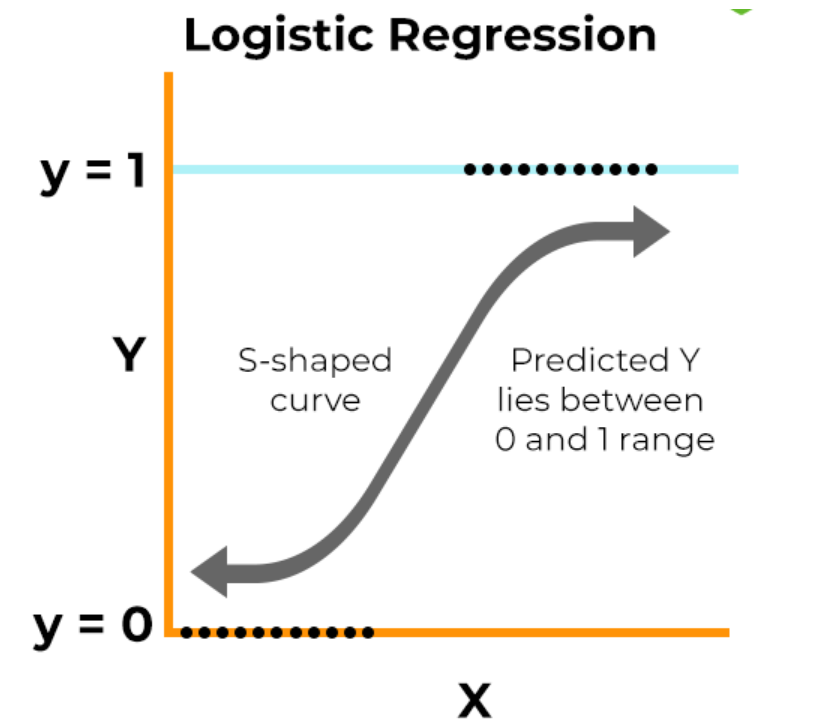

**There are several general assumptions that must be met to apply logistic regression.**
* The outcome variable is binary
* Little or no multicollinearity between explanatory variables
* Linear relationship of independent variables to log odds
* Requires a sufficent sample size
* No extreme outliers
* Independent observations


## Pip Install

In [1]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.2 MB/s eta 0:00:00


## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from google.colab import drive   # if not using colab comment this line out with a #
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## Load the data

In [5]:
# mount drive
drive.mount('/content/drive')   # if not using colab comment this line out with a #

Mounted at /content/drive


In [8]:
# change directory
os.chdir('/content/drive/MyDrive/Datasets')   # if not using colab comment this line out with a #

In [30]:
# load data
df = pd.read_csv('Airline customer satisfaction GoogleD.csv')

#df.head()
df.tail()

,Gender,Customer Type,Age,Type of,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
129875,1,0,34,1,2,526,3,3,3,1,...,4,3,2,4,4,5,4,0,0,0
129876,1,1,23,1,2,646,4,4,4,4,...,4,4,5,5,5,5,4,0,0,1
129877,0,1,17,0,0,828,2,5,1,5,...,2,4,3,4,5,4,2,0,0,0
129878,1,1,14,1,2,1127,3,3,3,3,...,4,3,2,5,4,5,4,0,0,1
129879,0,1,42,0,0,264,2,5,2,5,...,1,1,2,1,1,1,1,0,0,0


## Basic EDA

In [31]:
df.describe()

,Gender,Customer Type,Age,Type of,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,...,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,0.492616,0.816908,39.427957,0.690584,1.029650,1190.316392,2.728696,3.057599,2.756876,2.976925,...,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,18.752618,0.434463
std,0.499947,0.386743,15.119360,0.462255,0.962636,997.452477,1.329340,1.526741,1.401740,1.278520,...,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,93.184968,0.495688
min,0.000000,0.000000,7.000000,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,27.000000,0.000000,0.000000,414.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,40.000000,1.000000,1.000000,844.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,51.000000,1.000000,2.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000,1.000000
max,1.000000,1.000000,85.000000,1.000000,2.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,3981.000000,1.000000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype
---  ------                             --------------   -----
 0   Gender                             129880 non-null  int64
 1   Customer Type                      129880 non-null  int64
 2   Age                                129880 non-null  int64
 3   Type of                            129880 non-null  int64
 4   Class                              129880 non-null  int64
 5   Flight Distance                    129880 non-null  int64
 6   Inflight wifi service              129880 non-null  int64
 7   Departure/Arrival time convenient  129880 non-null  int64
 8   Ease of Online booking             129880 non-null  int64
 9   Gate location                      129880 non-null  int64
 10  Food and drink                     129880 non-null  int64
 11  Online boarding                    129880 non-null  int64
 12  Se

In [33]:
# Count number of full line duplicates
sum(df.duplicated())

0

In [34]:
df.notnull().sum()
# so data is clean and no problem with missing values

,0
Gender,129880
Customer Type,129880
Age,129880
Type of,129880
Class,129880
Flight Distance,129880
Inflight wifi service,129880
Departure/Arrival time convenient,129880
Ease of Online booking,129880
Gate location,129880


[Text(0.5, 1.0, 'Checking how balanced the outcome variable is')]

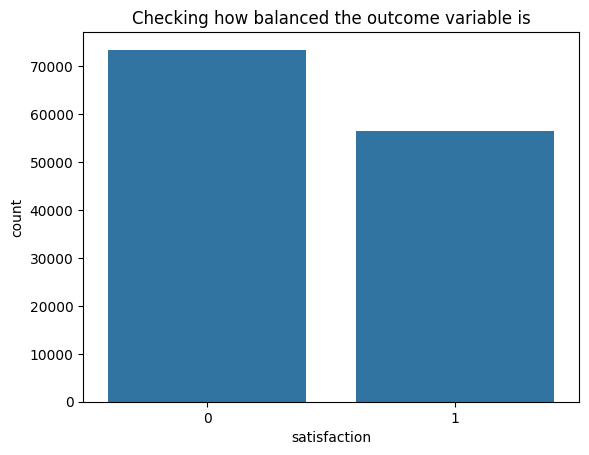

In [35]:
# Is the dataset unbalanced?

g = sns.countplot(data=df, x='satisfaction')
g.set(title='Checking how balanced the outcome variable is')

# The plot below is slightly unbalanced but not extremely so. We should be ok to proceed

## Split into train and test split

In [36]:
# train test split
from sklearn.model_selection import train_test_split

# We have retained 20% of the data for the test set
df_train, df_test = train_test_split(df, test_size=0.2, random_state=1234, stratify=df['satisfaction'])


In [37]:
# check the proportion split of satisfaction variable within the train and test sets
print(df_train['satisfaction'].value_counts(normalize=True))
print(df_test['satisfaction'].value_counts(normalize=True))

satisfaction
0    0.565541
1    0.434459
Name: proportion, dtype: float64
satisfaction
0    0.565522
1    0.434478
Name: proportion, dtype: float64


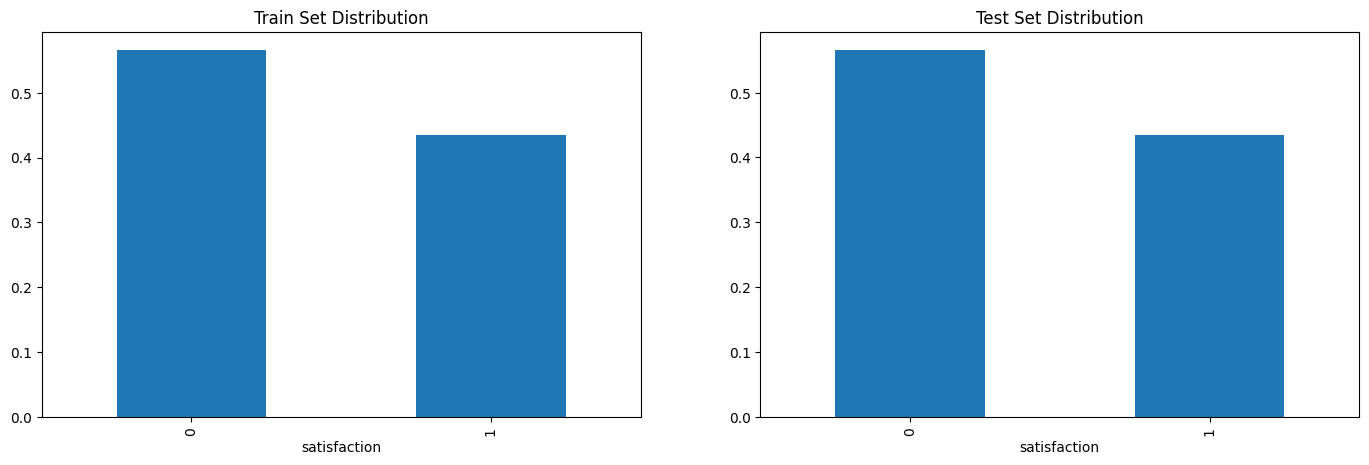

In [38]:
# verify the train test split

fig, axs = plt.subplots(ncols=2, figsize=(17, 5))
df_train['satisfaction'].value_counts(normalize=True).plot(kind='bar', ax=axs[0])
axs[0].set_title("Train Set Distribution")

df_test['satisfaction'].value_counts(normalize=True).plot(kind='bar', ax=axs[1])
axs[1].set_title('Test Set Distribution')
plt.show()

## EDA on the train set

In [39]:
corr = df_train.corr(numeric_only = True)
corr


,Gender,Customer Type,Age,Type of,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
Gender,1.000000,0.030549,0.009617,-0.008806,0.006312,0.003817,0.004577,0.008865,0.005524,-0.002188,...,0.001949,0.007252,0.030195,0.035960,0.008771,0.037833,0.001925,0.002722,-0.001623,0.009749
Customer Type,0.030549,1.000000,0.283644,-0.308336,0.104811,0.224897,0.006200,0.205666,0.017566,-0.005633,...,0.106390,0.053889,0.047126,-0.025423,0.031215,-0.023212,0.081565,-0.004678,0.005043,0.184092
Age,0.009617,0.283644,1.000000,0.047304,0.141882,0.101470,0.016503,0.034702,0.024126,0.000798,...,0.075602,0.057901,0.040160,-0.049203,0.032133,-0.051762,0.051891,-0.009364,-0.005302,0.133597
Type of,-0.008806,-0.308336,0.047304,1.000000,0.546609,0.268601,0.106049,-0.257541,0.134784,0.030629,...,0.153723,0.059497,0.140085,0.032400,-0.014436,0.023902,0.085500,0.005768,0.004309,0.450584
Class,0.006312,0.104811,0.141882,0.546609,1.000000,0.452392,0.036858,-0.091136,0.108466,0.008116,...,0.196537,0.210353,0.204567,0.161045,0.151351,0.154514,0.140492,-0.010850,0.004063,0.492384
Flight Distance,0.003817,0.224897,0.101470,0.268601,0.452392,1.000000,0.007598,-0.021052,0.065589,0.004152,...,0.131701,0.111422,0.135333,0.065741,0.071713,0.058824,0.095890,0.001104,0.033339,0.297920
Inflight wifi service,0.004577,0.006200,0.016503,0.106049,0.036858,0.007598,1.000000,0.346079,0.714671,0.339187,...,0.207312,0.120102,0.159248,0.122067,0.046640,0.109518,0.130228,-0.014545,-0.003145,0.285229
Departure/Arrival time convenient,0.008865,0.205666,0.034702,-0.257541,-0.091136,-0.021052,0.346079,1.000000,0.438526,0.448351,...,-0.008981,0.068950,0.011102,0.072497,0.091612,0.071944,0.009539,0.001773,0.001389,-0.055850
Ease of Online booking,0.005524,0.017566,0.024126,0.134784,0.108466,0.065589,0.714671,0.438526,1.000000,0.459428,...,0.046576,0.039904,0.108092,0.041317,0.010945,0.033746,0.014856,-0.004873,0.002498,0.171550
Gate location,-0.002188,-0.005633,0.000798,0.030629,0.008116,0.004152,0.339187,0.448351,0.459428,1.000000,...,0.002259,-0.028254,-0.005494,0.000862,-0.039622,-0.000695,-0.005783,0.006597,0.004504,-0.003583


Notice the correlation between pairs of features, like age and pregnancies, or insulin and skin thickness.

<Axes: >

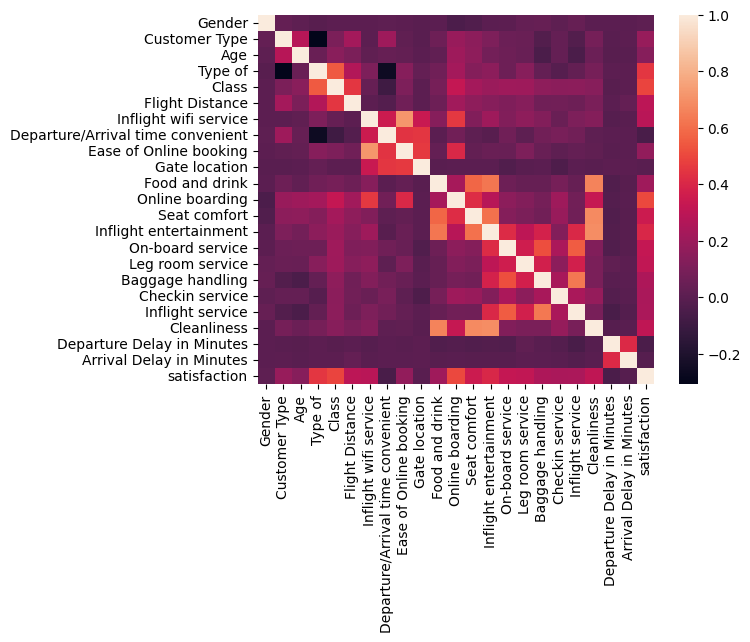

In [40]:
sns.heatmap(corr,
         xticklabels=corr.columns,
         yticklabels=corr.columns)

<Axes: xlabel='satisfaction', ylabel='Gender'>

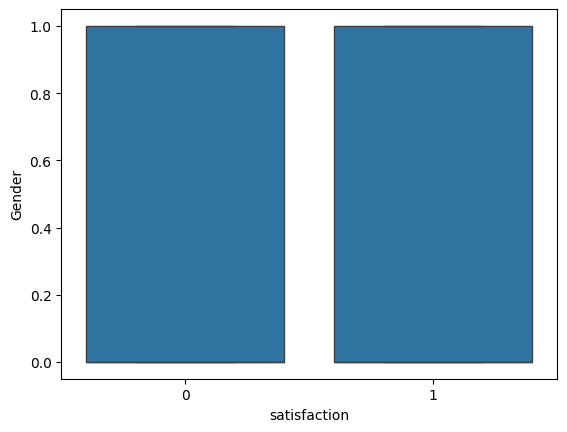

In [41]:
# look for outliers
# just one example here but see EDA topic 1
sns.boxplot(y="Gender", x = "satisfaction", data=df_train)

In [ ]:
# do some more boxplots yourself- Copy and paste the above cell and change the y variable



In [42]:
df_train.head()

,Gender,Customer Type,Age,Type of,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
61017,0,1,30,1,2,1538,4,4,4,4,...,4,5,1,2,1,2,4,0,6,1
45762,0,1,47,1,2,1547,1,1,1,1,...,4,4,4,4,4,4,4,21,20,1
73985,1,1,41,1,2,214,1,1,1,1,...,5,5,4,5,2,5,3,114,125,1
87762,0,1,60,0,0,160,2,5,0,2,...,3,3,0,3,5,3,5,0,0,0
94121,1,1,49,0,0,462,2,4,5,4,...,4,4,2,4,5,4,4,0,17,0


In [43]:
# Now we need to separate out the outcome variable that we are trying to predict (the 'y' variable)

X_train = df_train.drop('satisfaction', axis=1)
X_test = df_test.drop('satisfaction', axis=1)

y_train = df_train['satisfaction']
y_test = df_test['satisfaction']

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(103904, 22)
(25976, 22)
(103904,)
(25976,)


In [44]:
X_train.head()

,Gender,Customer Type,Age,Type of,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
61017,0,1,30,1,2,1538,4,4,4,4,...,4,4,5,1,2,1,2,4,0,6
45762,0,1,47,1,2,1547,1,1,1,1,...,5,4,4,4,4,4,4,4,21,20
73985,1,1,41,1,2,214,1,1,1,1,...,5,5,5,4,5,2,5,3,114,125
87762,0,1,60,0,0,160,2,5,0,2,...,4,3,3,0,3,5,3,5,0,0
94121,1,1,49,0,0,462,2,4,5,4,...,4,4,4,2,4,5,4,4,0,17


## Train the Model

In [45]:
# train logistic regression (unscaled)
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as met

# step 1: initialise the model
model = LogisticRegression()

# step 2: train the model
model.fit(X_train, y_train)

# step 3: generate y_pred
y_pred = model.predict(X_test)
y_pred



array([0, 1, 1, ..., 0, 0, 1])

## Scale the data

In [46]:
# scaling the data
# StandardScaler rescales the data to have a mean of 0 and a standard deviation of 1.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")  # returns a pandas df rather than nupmy array
scaler.fit(X_train)   # You fit on the train set
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)     # This uses the fit from the training set not the test!!!



In [48]:

print(X_train['Age'].mean())
print(X_train_scaled['Age'].mean())
print(X_train_scaled['Age'].std())


39.406500230982445
2.2190783584284773e-17
1.0000048121690024


In [49]:
# training with the scaled data

# step 1: initialise the model
model_scaled = LogisticRegression()

# step 2: train the model
model_scaled.fit(X_train_scaled, y_train)

# step 3: generate y_pred
y_pred_scaled_model = model_scaled.predict(X_test_scaled)


# Assessing Model

### Remember:
* Accuracy is the proportion we predicted correctly
* Precision is the proportion of predicted positives that are correct
* Recall = sensitivity = True Positive Rate =  is the proportion of all actual postitives that were predicted as positives
* Specificity — The proportion of actual negatives that were predicted to be negative
* F1 score is a measure that combines precision and recall: F1 Score = 2 * (Precision * Recall) / (Precision + Recall)

In [50]:
# Useful read:
# https://datascience.stackexchange.com/questions/73974/balanced-accuracy-vs-f1-score

# Metrics for the Model that uses unscaled data
accuracy = met.accuracy_score(y_test, y_pred)
balanced_accuracy = met.balanced_accuracy_score(y_test, y_pred)
f1 = met.f1_score(y_test, y_pred)

print("Accuracy stats for the unscaled data model:")
print("Accuracy:", np.round(accuracy*100.0,1))
print("Balanced Accuracy:", np.round(balanced_accuracy*100.0,2)) # Average of sensitivity and specificity (V useful when unbalanced)

print("F1-score: ", np.round(f1*100.0,2)) # F1 score doesn't care about how many true negatives are being classified

Accuracy stats for the unscaled data model:
Accuracy: 78.4
Balanced Accuracy: 78.53
F1-score:  76.19


In [51]:
# Metrics for the Model that uses scaled data
accuracy = met.accuracy_score(y_test, y_pred_scaled_model)
balanced_accuracy = met.balanced_accuracy_score(y_test, y_pred_scaled_model)
f1 = met.f1_score(y_test, y_pred_scaled_model)

print("Accuracy stats for the scaled data model:")
print("Accuracy:", np.round(accuracy*100.0,1))
print("Balanced Accuracy:", np.round(balanced_accuracy*100.0,2)) # Average of sensitivity and specificity (V useful when unblanced)

print("F1-score: ", np.round(f1*100.0,2))

Accuracy stats for the scaled data model:
Accuracy: 87.6
Balanced Accuracy: 87.16
F1-score:  85.46


###  Confusion Matrix

In [52]:
# this is a basic confusion matrix
cm = met.confusion_matrix(y_test, y_pred)
print(cm)
                      # PREDICTED
#                     0                     1
# ACTUAL  0    # True Negative       False Positive
#         1    # False Negative      True Positive

[[11390  3300]
 [ 2310  8976]]


In [53]:
cm = met.confusion_matrix(y_test, y_pred_scaled_model)
print(cm)

[[13259  1431]
 [ 1798  9488]]


In [54]:
# confusion matrix plot
# This is a FUNCTION we are telling Python what to do when the function is called - ie plot a confusion matrix heatmap
# NOTE - There is no output from this cell as the function has not been called yet - that is below
def visualize_classification(y_test, y_pred):
    """
    Visualizes the classification performance by displaying a classification report
    and a confusion matrix heatmap.
    """
    # Generate and print the classification report
    from sklearn.metrics import classification_report
    from sklearn.metrics import confusion_matrix
    cr = classification_report(y_test, y_pred)
    print("Classification Report:")
    print(cr)
    # Generate the confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred.round())

    # Create the heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix Heatmap')
    plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     14690
           1       0.87      0.84      0.85     11286

    accuracy                           0.88     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.88      0.88      0.88     25976



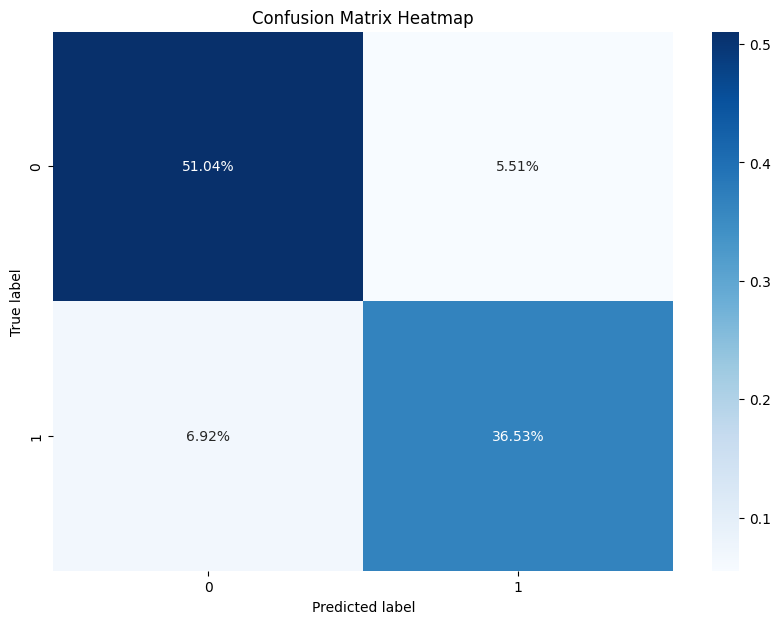

In [55]:
visualize_classification(y_test, y_pred_scaled_model)
# Remember:
# precision is the proportion of predicted positives that are correct ( = positive predictive value)
# recall is the proportion of all actual postitives that were predicted as positives
# F1 score is a measure that combines precision and recall: F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
# The support is the number of samples of the true response that lie in that class.

## Method below shows an enhanced matrix with ROC curve
I am not expecting you to create code like this but feel free to use it!

In [56]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def plot_roc_cm(y_true, y_pred, model, name):
    # compute fpr and tpr for roc curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    # compute the confusion matrix
    y_pred_binary = np.where(y_pred > 0.5, 1, 0)
    mat = confusion_matrix(y_true, y_pred_binary)
    cr = classification_report(y_true, y_pred_binary)
    print(cr)

    # plot the ROC curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
    ax1.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    ax1.plot([0, 1], [0, 1], 'k--')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve of {}'.format(name))
    ax1.legend(loc='lower right')

    # plot the confusion matrix
    names = ["True Negative", "False Positive", "False Negative", "True Positive"]
    counts = ["{0:0.0f}".format(value) for value in mat.flatten()]
    percents = ["{0:.2%}".format(value) for value in mat.flatten()/np.sum(mat)]
    labels = ["{}\n{}\n{}".format(a, b, c) for a, b, c in zip(names, counts, percents)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(mat, annot=labels, fmt="", cmap="Blues", ax=ax2)
    ax2.set(xlabel="Predicted", ylabel="Actual",
       title='Confusion Matrix of {}'.format(name))

    plt.tight_layout()
    plt.show()

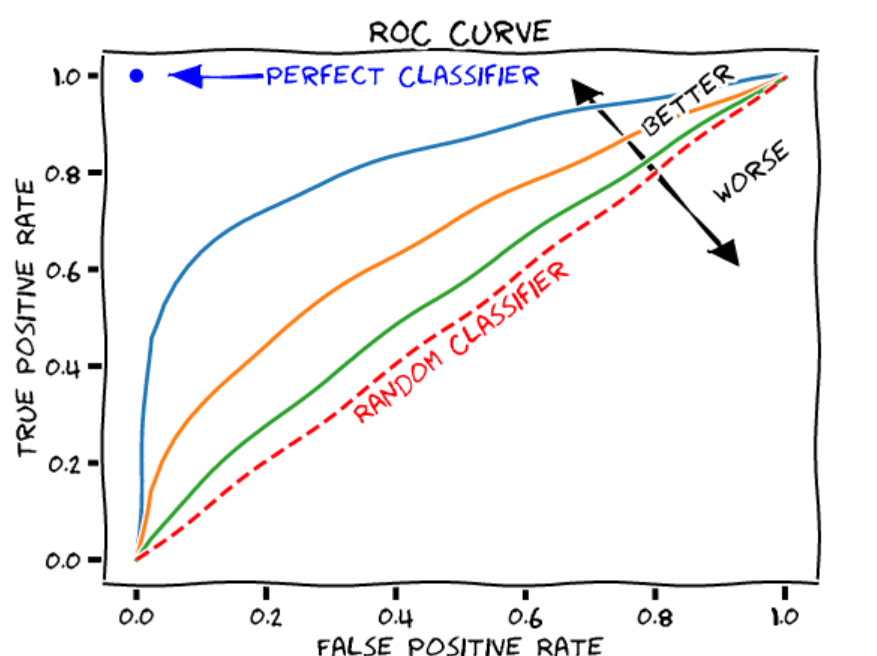

## Definitions
### TPR = TP / (TP + FN) i.e. proportion of actual positive that were predicted correctly
### FPR = FP/FP+TN i.e. proportion of actual negatives that we predicted positive
## Note:
### Bottom Left corresponds with threshold = 1 ie we predict negative always
### Top right correspons to threshold = 0 ie we predict positive always
https://analyticsindiamag.com/beginners-guide-to-understanding-roc-curve-how-to-find-the-perfect-probability-threshold/

              precision    recall  f1-score   support

           0       0.88      0.90      0.89     14690
           1       0.87      0.84      0.85     11286

    accuracy                           0.88     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.88      0.88      0.88     25976



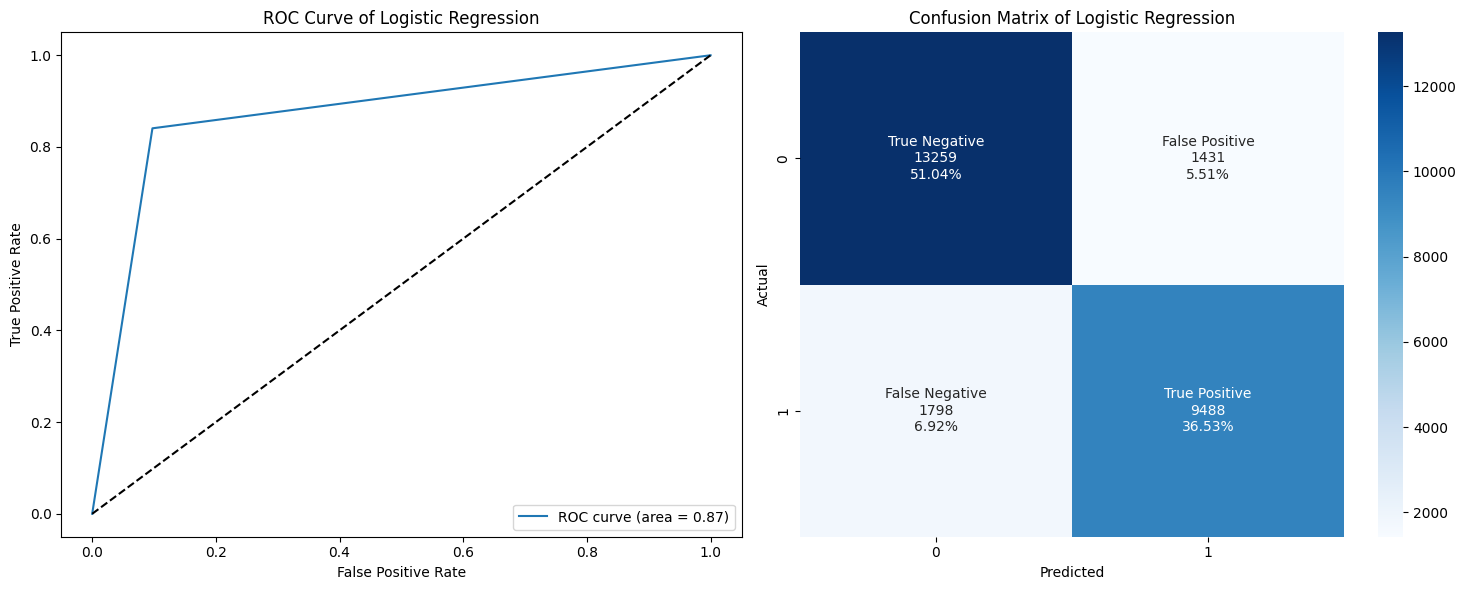

In [57]:
plot_roc_cm(y_test, y_pred_scaled_model, model_scaled, 'Logistic Regression')

# Interpreting the ML Model

In [58]:
coeff_df = pd.DataFrame(zip(X_train.columns, model_scaled.coef_[0]))
coeff_df.columns = ["feature","coefficient"]
coeff_df['exp'] = np.exp(coeff_df['coefficient'])
coeff_df

,feature,coefficient,exp
0,Gender,0.025648,1.025980
1,Customer Type,0.771308,2.162593
2,Age,-0.125133,0.882380
3,Type of,1.272043,3.568135
4,Class,0.331454,1.392992
5,Flight Distance,0.004274,1.004283
6,Inflight wifi service,0.529576,1.698211
7,Departure/Arrival time convenient,-0.216135,0.805627
8,Ease of Online booking,-0.185612,0.830595
9,Gate location,0.023345,1.023620


Text(0.5, 0, 'Importance')

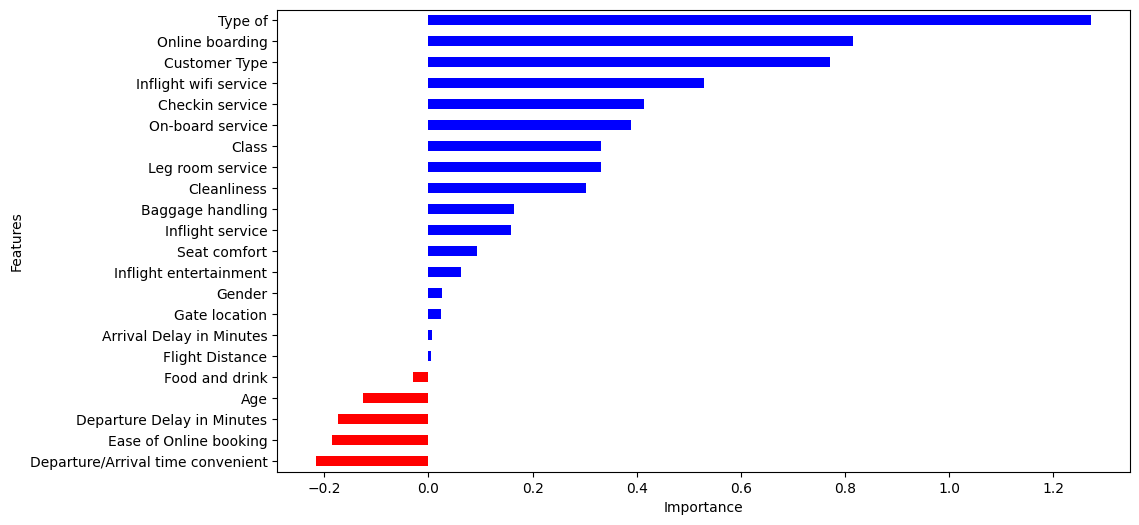

In [59]:
# Plotting the coefficients

coeff = list(model_scaled.coef_[0])
labels = list(X_train.columns)
features = pd.DataFrame()
features['Features'] = labels
features['importance'] = coeff
features.sort_values(by=['importance'], ascending=True, inplace=True)
features['positive'] = features['importance'] > 0
features.set_index('Features', inplace=True)
features.importance.plot(kind='barh', figsize=(11, 6),color = features.positive.map({True: 'blue', False: 'red'}))
plt.xlabel('Importance')

# Overall findings

### 1) The model has an overall accuracy of 82% which is well above the 50% expected by pure chance
(Note be careful using just accuracy as it depends on the sitation e.g. say the data set is very unbalanced and only 5% have the outcome we are trying to predict (eg diabetes here). Then if we had no model and always predicted a 0 we would expect to have an accuracy rate around 95% but it's not helping us find the 5% we are worried about!!!)

### 2) Unfortunately, the type 2 error rate (False negatives) is relatively high at 12%. This is important in this scenario as we are missing diabetes being found. Type 2 errors are more of an issue than type 1 errors in this case. We recommend that further investigation and modelling is performed to try to improve this error rate.

### 3) Glucose level, BMI, pregnancies and diabetes pedigree function have significant influence on the model, specially glucose level and BMI

### 4) Blood pressure has a negative influence on the prediction

# **Extra**
### The code below runs lots of different classification methods in one go. You are not expected to understand all of these. We are showing here that Logistic Regression is actually performing well relative to the others

In [ ]:
# This uses lots of different method to predict

from lazypredict.Supervised import LazyClassifier

# load the lazyclassifier engine - specify settings
classifier = LazyClassifier(verbose=0, ignore_warnings=True,
                     custom_metric=None, predictions=True)

# run the lazyclassifier engine
models, predictions = classifier.fit(X_train, X_test, y_train, y_test)

In [1]:
models.sort_values(by=['F1 Score','Balanced Accuracy'], ascending=False, axis=0)

NameError: name 'models' is not defined

## Feature transformations


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


### Example 1 create a variable from grouping data values

In [ ]:
# keep as an example of feature transformation

def categorize_bmi(bmi):
    """
    Categorizes the BMI value into different weight classes.
    """
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 25:
        return "Normal weight"
    elif 25 <= bmi < 30:
        return "Overweight"
    else:
        return "Obesity"

df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

#df = df.drop('BMI_Category', axis=1)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category
0,6,148,72,35,0,33.60,0.63,50,1,Obesity
1,1,85,66,29,0,26.60,0.35,31,0,Overweight
2,8,183,64,0,0,23.30,0.67,32,1,Normal weight
3,1,89,66,23,94,28.10,0.17,21,0,Overweight
4,0,137,40,35,168,43.10,2.29,33,1,Obesity


### Insulin per BMI

In [ ]:
# Insulin per BMI
df['Insulin_per_BMI'] = df['Insulin'] / df['BMI']

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0 33.60   
1            1       85             66             29        0 26.60   
2            8      183             64              0        0 23.30   
3            1       89             66             23       94 28.10   
4            0      137             40             35      168 43.10   

   DiabetesPedigreeFunction  Age  Outcome   BMI_Category  Insulin_per_BMI  
0                      0.63   50        1        Obesity             0.00  
1                      0.35   31        0     Overweight             0.00  
2                      0.67   32        1  Normal weight             0.00  
3                      0.17   21        0     Overweight             3.35  
4                      2.29   33        1        Obesity             3.90  


## Encoding Categorical variables

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Insulin_per_BMI
0,6,148,72,35,0,33.60,0.63,50,1,Obesity,0.00
1,1,85,66,29,0,26.60,0.35,31,0,Overweight,0.00
2,8,183,64,0,0,23.30,0.67,32,1,Normal weight,0.00
3,1,89,66,23,94,28.10,0.17,21,0,Overweight,3.35
4,0,137,40,35,168,43.10,2.29,33,1,Obesity,3.90


In [ ]:
dummies = pd.get_dummies(df.BMI_Category,dtype='int',drop_first=True)
df = pd.concat([df, dummies], axis=1)

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0 33.60   
1            1       85             66             29        0 26.60   
2            8      183             64              0        0 23.30   
3            1       89             66             23       94 28.10   
4            0      137             40             35      168 43.10   

   DiabetesPedigreeFunction  Age  Outcome   BMI_Category  Insulin_per_BMI  \
0                      0.63   50        1        Obesity             0.00   
1                      0.35   31        0     Overweight             0.00   
2                      0.67   32        1  Normal weight             0.00   
3                      0.17   21        0     Overweight             3.35   
4                      2.29   33        1        Obesity             3.90   

   Obesity  Overweight  Underweight  
0        1           0            0  
1        0           1      